In [1]:
import os, sys, csv, json, h5py, random, math, pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

from allensdk.api.queries.biophysical_api import BiophysicalApi
from allensdk.model.biophys_sim.config import Config
from allensdk.model.biophysical.utils import Utils

from modules import download_cell
from modules import build_cell
from modules import run_sim
from modules import plotting


--No graphics will be displayed.


In [2]:
syn_params = {
    'stim': {
            'type': "AMPA_NMDA_STP",
            'N_syn': 50, # num of syns generated; if None uses dist_func
            'segs': 'all', # 'all', 'proximal', 'distal'
            'dist_func': lambda d: 2.0,
            'freq': '/home/hrbncv/SCP/external_data/bio_cell_output/pyrFiringRateAvg.csv', # constant, or .csv fp for inhomog input
            # 'freq': '/home/hrbncv/SCP/external_data/bio_cell_output/pyrFiringRateAvg_inh_adjusted.csv', # constant, or .csv fp for inhomog input

            'wt_mean': 0.5, 
            'wt_std': (0.17/0.5), # bio data shows about 0.17/0.5 of mean

            'initW': 1.0,
            'gmax_AMPA': 0.001, #uS
            'gmax_NMDA': 0.001, #uS
            'tau_r_AMPA': 4,
            'tau_d_AMPA': 5,
            'Use': 0.4,
            'Dep': 0,
            'Fac': 70, #80
            'NMDA_ratio': 1.5
        },
}

# Set sim parameters
sim_params = {
    'dt': 0.025, # ms
    'delay': 500, #ms
    'tstart': 200, # ms
    'tstop': 1200, # ms
    'bins': 5, # ms; for spike train gen/sim, not plotting
}

In [3]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from typing import Union

TIME_CANDIDATES = [
    r'^time$', r'^t$', r'^t_?ms$', r'^(ms|msec|millisecond)s?$',
    r'^t_?s$', r'^(s|sec|second)s?$'
]
RATE_CANDIDATES = [
    r'^(rate|r|firing(_rate)?)$', r'^(hz)$', r'^(spikes?_per_?s|spikes?/s)$'
]

def _find_col(name_list, cols):
    cols_lower = [c.lower() for c in cols]
    for pat in name_list:
        rx = re.compile(pat, re.IGNORECASE)
        for i, c in enumerate(cols_lower):
            if rx.match(c):
                return i
    return None

def inspect_pn_csv(csv_path: Union[str, Path], max_rows: int = 5):
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)
    cols = list(df.columns)

    # Try to detect time & rate columns by header names
    tidx = _find_col(TIME_CANDIDATES, cols)
    ridx = _find_col(RATE_CANDIDATES, cols)

    # Heuristics if headers aren’t clear
    if tidx is None and len(df.columns) > 0:
        first = df.iloc[:, 0]
        if np.issubdtype(first.dtype, np.number):
            vals = first.values
            if vals.size >= 3 and np.all(np.diff(vals[:min(len(vals), 1000)]) > 0):
                tidx = 0

    if ridx is None:
        candidate_idxs = [i for i, c in enumerate(cols) if np.issubdtype(df.iloc[:, i].dtype, np.number)]
        if tidx == 0 and len(candidate_idxs) > 1:
            ridx = 1
        elif candidate_idxs:
            ridx = candidate_idxs[-1]

    # Extract arrays (if present)
    t = df.iloc[:, tidx].to_numpy(dtype=float) if tidx is not None else None
    r = df.iloc[:, ridx].to_numpy(dtype=float) if ridx is not None else None

    # Guess time units and dt
    time_unit = None
    dt_ms = None
    if t is not None and t.size > 1:
        diffs = np.diff(t[:min(len(t), 500)])
        diffs = diffs[np.isfinite(diffs)]
        med_dt = float(np.median(diffs)) if diffs.size else None
        if med_dt is not None:
            if 1e-4 <= med_dt <= 1e-1:
                time_unit = 's'
                dt_ms = med_dt * 1000.0
            else:
                time_unit = 'ms'
                dt_ms = med_dt

    print("=== PN CSV Inspection ===")
    print(f"Path: {csv_path}")
    print(f"Columns: {cols}")
    print(f"Detected time column index: {tidx}  ({cols[tidx] if tidx is not None else 'None'})")
    print(f"Detected rate column index: {ridx}  ({cols[ridx] if ridx is not None else 'None'})")
    if t is not None:
        print(f"Time unit guess: {time_unit} | dt_ms≈ {None if dt_ms is None else round(dt_ms, 4)}")
        print(f"Time span: {round(t[0],4)} → {round(t[-1],4)} ({time_unit or 'unknown'})")
    else:
        print("No time column detected. We’ll need you to specify dt_ms explicitly.")
    if r is not None:
        print(f"Rate stats (Hz): min={np.nanmin(r):.3f}, max={np.nanmax(r):.3f}, median={np.nanmedian(r):.3f}")
        print("First rows:")
        print(df.head(max_rows).to_string(index=False))
    else:
        print("No rate column detected. Please confirm which column is PN firing rate (Hz).")

    return {
        "df": df,
        "time_idx": tidx, "rate_idx": ridx,
        "time_unit": time_unit, "dt_ms": dt_ms
    }


In [4]:

# EXAMPLE USAGE:
info = inspect_pn_csv("/home/hrbncv/SCP/external_data/bio_cell_output/pyrFiringRateAvg.csv")

=== PN CSV Inspection ===
Path: /home/hrbncv/PV-SST/single_cells/Madhu_Data/bio_cell_output/pyrFiringRateAvg.csv
Columns: ['Time', 'AvgFiringRate']
Detected time column index: 0  (Time)
Detected rate column index: 1  (AvgFiringRate)
Time unit guess: s | dt_ms≈ 5.0239
Time span: -0.5 → 0.55 (s)
Rate stats (Hz): min=1.764, max=8.841, median=2.378
First rows:
     Time  AvgFiringRate
-0.500000       1.832524
-0.494976       1.777913
-0.489952       1.910059
-0.484928       1.856796
-0.479904       1.763754


In [ ]:
# import pandas as pd
# import numpy as np
# from pathlib import Path

# # === CONFIG ===
# tau_s    = 0.05   # <-- time constant in seconds (try 0.2–0.6 first)
# init_mode = "match"  # "match" sets S0 = r_norm(0); "zero" sets S0 = 0
# src_path = Path("/home/hrbncv/SCP/external_data/bio_cell_output/pyrFiringRateAvg.csv")
# out_path = src_path.with_name(src_path.stem + f"_gabab_tau{tau_s}.csv")   # same columns, new file

# # === LOAD ===
# df = pd.read_csv(src_path)
# t = df.iloc[:, 0].to_numpy(dtype=float)        # seconds
# r = df.iloc[:, 1].to_numpy(dtype=float)        # Hz
# N = r.size
# assert N > 2, "Trace too short."

# # dt in seconds (use median in case of tiny jitter)
# dt = float(np.median(np.diff(t)))
# if not (1e-4 <= dt <= 1.0):
#     raise ValueError(f"Unexpected dt (s): {dt}")

# # === STEP 1: normalize ===
# rmax = max(r.max(), 1e-12)
# r_norm = r / rmax

# # === STEP 2: integrate S' = (r_norm - S)/tau ===
# S = np.zeros_like(r_norm)
# S[0] = r_norm[0] if init_mode == "match" else 0.0
# coef = dt / tau_s
# for i in range(1, N):
#     S[i] = S[i-1] + coef * (r_norm[i-1] - S[i-1])
# # keep S in [0,1] just in case of numeric drift
# S = np.clip(S, 0.0, 1.0)

# # === STEP 3: effective PN->SST drive ===
# I = r * (1.0 - S)
# I[I < 0] = 0.0

# # === SAVE with SAME column names ===
# out_df = pd.DataFrame({df.columns[0]: t, df.columns[1]: I})
# out_df.to_csv(out_path, index=False)

# # === QUICK SUMMARY ===
# print("Wrote:", out_path)
# print(f"dt ≈ {dt*1000:.3f} ms, tau = {tau_s*1000:.1f} ms")
# print(f"Original rate: min={r.min():.3f} max={r.max():.3f} Hz")
# print(f"Adjusted rate: min={I.min():.3f} max={I.max():.3f} Hz")
# print("Preview:")
# print(out_df.head().to_string(index=False))


Wrote: /home/hrbncv/PV-SST/single_cells/Madhu_Data/bio_cell_output/pyrFiringRateAvg_gabab_tau0.05.csv
dt ≈ 5.024 ms, tau = 50.0 ms
Original rate: min=1.764 max=8.841 Hz
Adjusted rate: min=1.347 max=4.257 Hz
Preview:
     Time  AvgFiringRate
-0.500000       1.452687
-0.494976       1.409395
-0.489952       1.515337
-0.484928       1.471329
-0.479904       1.397173


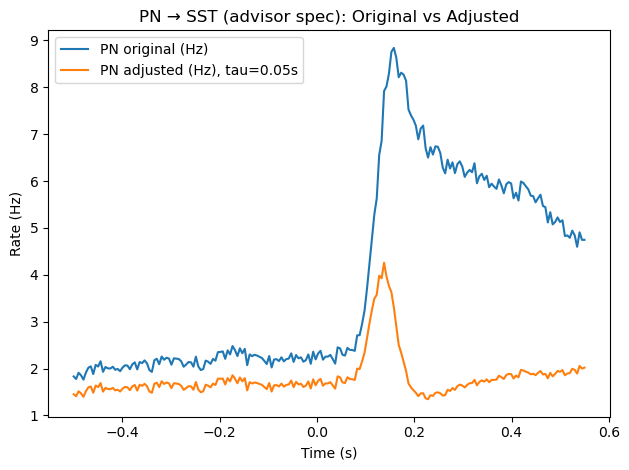

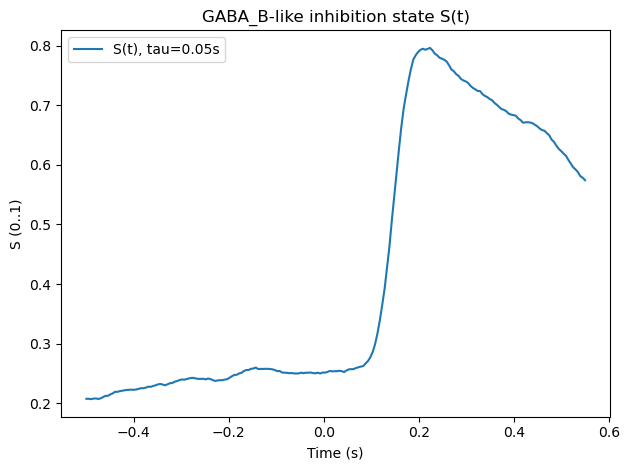

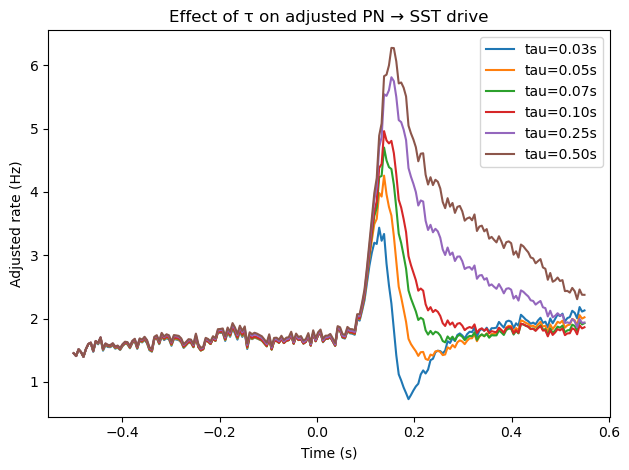

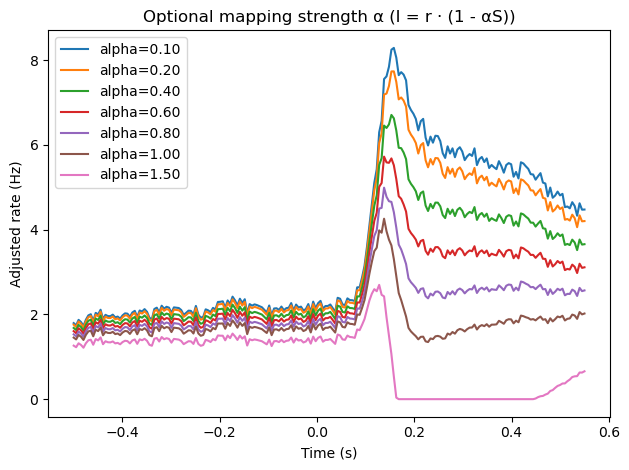

In [15]:
# === PN → SST (advisor spec) visualization ===
# Plots: original vs adjusted; S(t); tau sweep; (optional) alpha sweep
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- Config ----------
src_path = Path("/home/hrbncv/SCP/external_data/bio_cell_output/pyrFiringRateAvg.csv")
baseline_tau_s = 0.05            # main time constant (seconds)
init_mode = 'match'              # "match" (S0=r_norm(0)) or "zero"
tau_sweep = [0.025, 0.05, 0.075, 0.1, 0.25, 0.5]   # seconds
SHOW_ALPHA_SWEEP = True         # set True to view optional α sweep
alpha_sweep = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5]  # α=1.0 == original spec; <1 weakens inhibition
use_percentile_norm = False      # set True to normalize by 99th percentile instead of max (robust to outliers)
pctl = 99.0

# ---------- Load ----------
df = pd.read_csv(src_path)
t = df.iloc[:, 0].to_numpy(dtype=float)  # seconds
r = df.iloc[:, 1].to_numpy(dtype=float)  # Hz
dt = float(np.median(np.diff(t)))
assert 1e-4 <= dt <= 1.0, f"Unexpected dt: {dt}s"

# ---------- Helper: advisor’s model ----------
def apply_gabab_simple(r_hz, dt_s, tau_s, init="match", alpha=1.0, *, robust_norm=False, pctl=99.0):
    """
    Advisor's equations:
      r_norm = r / r_max        (or percentile if robust_norm=True)
      dS/dt = (r_norm - S) / tau
      I = r * (1 - alpha * S)   (alpha=1.0 reproduces spec; <1 optional)
    """
    r = np.asarray(r_hz, dtype=float)
    if robust_norm:
        rmax = np.percentile(r, pctl)
    else:
        rmax = r.max()
    rmax = max(rmax, 1e-12)
    r_norm = r / rmax

    S = np.zeros_like(r_norm)
    S[0] = r_norm[0] if init == "match" else 0.0

    coef = dt_s / tau_s
    for i in range(1, r.size):
        S[i] = S[i-1] + coef * (r_norm[i-1] - S[i-1])
    S = np.clip(S, 0.0, 1.0)

    I = r * (1.0 - alpha * S)
    I[I < 0] = 0.0
    return I, S

# import numpy as np

# def apply_gabab_simple(
#     r_hz, dt_s, tau_s, *,
#     init="match",
#     alpha=1.0,
#     robust_norm=False, pctl=99.0,
#     delay_ms=0.0,         # NEW: delay in ms (e.g., 60–120)
#     gamma=1.0,            # NEW: mapping nonlinearity (1 == linear)
#     theta=0.0             # NEW: small threshold on S before it suppresses
# ):
#     """
#     Advisor core (unchanged):
#       r_norm = r / r_ref
#       dS/dt = (r_drive - S) / tau
#     Mapping (advisor when gamma=1, theta=0): I = r * (1 - alpha * S)

#     Tweaks:
#       - delay_ms shifts the r_norm drive into the past before feeding S (GABA_B latency)
#       - robust_norm uses percentile for r_ref
#       - gamma, theta only affect the mapping; ODE stays identical
#     """
#     r = np.asarray(r_hz, dtype=float)
#     N = r.size
#     # --- normalization ---
#     r_ref = np.percentile(r, pctl) if robust_norm else r.max()
#     r_ref = max(r_ref, 1e-12)
#     r_norm = r / r_ref

#     # --- delayed drive for S ---
#     k = int(round((delay_ms/1000.0) / max(dt_s, 1e-12)))
#     if k <= 0:
#         r_drive = r_norm
#     elif k >= N:
#         # extreme delay: drive is flat at initial level
#         base = r_norm[0] if init == "match" else 0.0
#         r_drive = np.full_like(r_norm, base)
#     else:
#         base = r_norm[0] if init == "match" else 0.0
#         r_drive = np.empty_like(r_norm)
#         r_drive[:k] = base
#         r_drive[k:] = r_norm[:-k]

#     # --- integrate S' = (r_drive - S)/tau ---
#     S = np.zeros_like(r_norm)
#     S[0] = r_norm[0] if init == "match" else 0.0
#     coef = dt_s / tau_s
#     for i in range(1, N):
#         S[i] = S[i-1] + coef * (r_drive[i-1] - S[i-1])
#     S = np.clip(S, 0.0, 1.0)

#     # --- mapping: I = r * (1 - alpha * S_eff^gamma) ---
#     if theta > 0.0:
#         # suppress only when S > theta
#         Se = np.clip((S - theta) / max(1e-9, 1.0 - theta), 0.0, 1.0)
#     else:
#         Se = S
#     if gamma != 1.0:
#         Se = Se ** gamma

#     I = r * (1.0 - alpha * Se)
#     I[I < 0] = 0.0
#     return I, S, r_drive


# ---------- Baseline ----------
I_base, S_base = apply_gabab_simple(
    r, dt, baseline_tau_s, init=init_mode, alpha=1.0,
    robust_norm=use_percentile_norm, pctl=pctl
)

# ---------- Fig 1: PN original vs adjusted (baseline) ----------
plt.figure()
plt.plot(t, r, label="PN original (Hz)")
plt.plot(t, I_base, label=f"PN adjusted (Hz), tau={baseline_tau_s:.2f}s")
plt.title("PN → SST (advisor spec): Original vs Adjusted")
plt.xlabel("Time (s)")
plt.ylabel("Rate (Hz)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Fig 2: Inhibition state S(t) ----------
plt.figure()
plt.plot(t, S_base, label=f"S(t), tau={baseline_tau_s:.2f}s")
plt.title("GABA_B-like inhibition state S(t)")
plt.xlabel("Time (s)")
plt.ylabel("S (0..1)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Fig 3: τ sweep (shape/duration of dip) ----------
plt.figure()
for tau in tau_sweep:
    I_tau, _ = apply_gabab_simple(
        r, dt, tau, init=init_mode, alpha=1.0,
        robust_norm=use_percentile_norm, pctl=pctl
    )
    plt.plot(t, I_tau, label=f"tau={tau:.2f}s")
plt.title("Effect of τ on adjusted PN → SST drive")
plt.xlabel("Time (s)")
plt.ylabel("Adjusted rate (Hz)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Fig 4 (optional): α sweep (dip strength) ----------
if SHOW_ALPHA_SWEEP:
    plt.figure()
    for a in alpha_sweep:
        I_a, _ = apply_gabab_simple(
            r, dt, baseline_tau_s, init=init_mode, alpha=a,
            robust_norm=use_percentile_norm, pctl=pctl
        )
        plt.plot(t, I_a, label=f"alpha={a:.2f}")
    plt.title("Optional mapping strength α (I = r · (1 - αS))")
    plt.xlabel("Time (s)")
    plt.ylabel("Adjusted rate (Hz)")
    plt.legend()
    plt.tight_layout()
    plt.show()


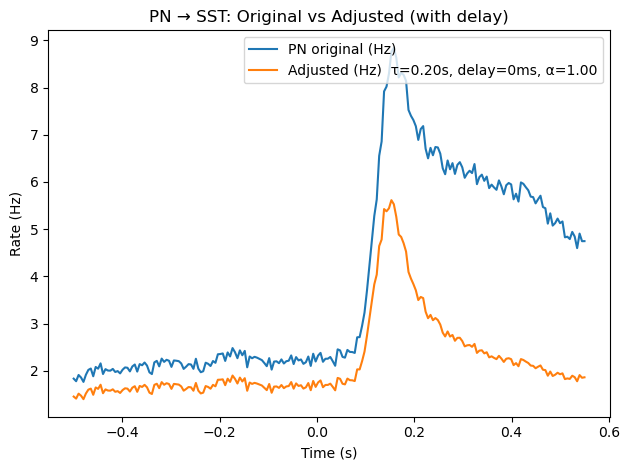

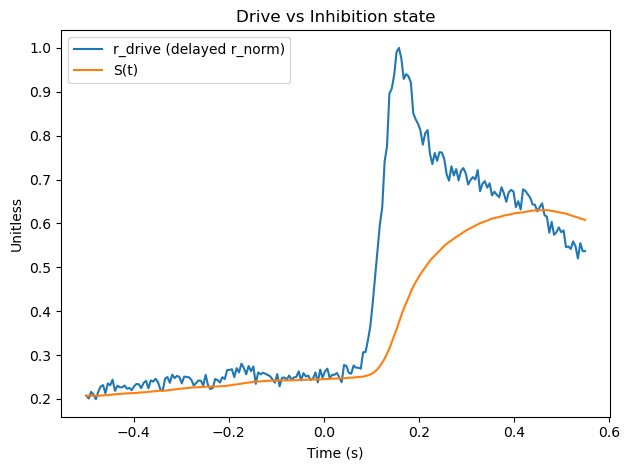

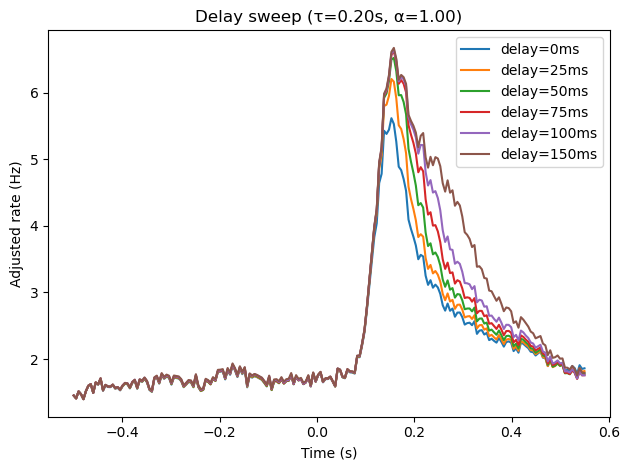

Wrote: /home/hrbncv/PV-SST/single_cells/Madhu_Data/bio_cell_output/pyrFiringRateAvg_gabab_tau200ms_delay0ms.csv


In [ ]:
# === PN → SST (advisor spec) with DELAY and DELAY SWEEP ===
# Equations:
#   r_norm = r / r_ref
#   dS/dt = (r_drive - S)/tau, where r_drive is r_norm delayed by delay_ms
#   I = r * (1 - alpha * S)    (alpha=1.0 exactly matches advisor’s mapping)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- Config (edit these) ----------
src_path = Path("/home/hrbncv/SCP/external_data/bio_cell_output/pyrFiringRateAvg.csv")

# Baseline settings for single-trace view
tau_s = 0.20              # seconds
delay_ms = 0.0           # milliseconds (try 60–120)
alpha = 1.0               # 1.0 == advisor’s mapping; <1 weakens suppression
init_mode = "match"       # "match" (S0=r_norm(0)) or "zero"

# Normalization options
use_percentile_norm = False  # False = use max; True = use percentile
pctl = 99.0                  # percentile if using robust normalization

# Sweep of delay values (ms) to visualize effect
delay_sweep_ms = [0.0, 25, 50.0, 75.0, 100.0, 150.0]

# Save the adjusted trace (using the single "delay_ms" baseline above)
SAVE = False

# ---------- Load ----------
df = pd.read_csv(src_path)
t = df.iloc[:, 0].to_numpy(dtype=float)  # seconds
r = df.iloc[:, 1].to_numpy(dtype=float)  # Hz
dt_s = float(np.median(np.diff(t)))
assert 1e-4 <= dt_s <= 1.0, f"Unexpected dt: {dt_s}s"

# ---------- Helper ----------
def apply_gabab_delayed(
    r_hz: np.ndarray,
    dt_s: float,
    tau_s: float,
    *,
    delay_ms: float = 0.0,
    alpha: float = 1.0,
    init: str = "match",
    robust_norm: bool = False,
    pctl: float = 99.0
):
    """
    Advisor core + delay:
      r_ref = max(r) or percentile
      r_norm = r / r_ref
      r_drive = delayed(r_norm, delay_ms)
      S' = (r_drive - S)/tau
      I = r * (1 - alpha * S)
    """
    r = np.asarray(r_hz, dtype=float)
    N = r.size

    # Normalization
    r_ref = np.percentile(r, pctl) if robust_norm else r.max()
    r_ref = max(r_ref, 1e-12)
    r_norm = r / r_ref

    # Delay (in samples)
    k = int(round((delay_ms / 1000.0) / max(dt_s, 1e-12)))
    if k <= 0:
        r_drive = r_norm
    elif k >= N:
        base = r_norm[0] if init == "match" else 0.0
        r_drive = np.full_like(r_norm, base)
    else:
        base = r_norm[0] if init == "match" else 0.0
        r_drive = np.empty_like(r_norm)
        r_drive[:k] = base
        r_drive[k:] = r_norm[:-k]

    # Integrate S
    S = np.zeros_like(r_norm)
    S[0] = r_norm[0] if init == "match" else 0.0
    coef = dt_s / tau_s
    for i in range(1, N):
        S[i] = S[i-1] + coef * (r_drive[i-1] - S[i-1])
    S = np.clip(S, 0.0, 1.0)

    # Map to adjusted PN→SST drive
    I = r * (1.0 - alpha * S)
    I[I < 0] = 0.0
    return I, S, r_drive

# ---------- Baseline plots ----------
I_base, S_base, r_drive_base = apply_gabab_delayed(
    r, dt_s, tau_s,
    delay_ms=delay_ms,
    alpha=alpha,
    init=init_mode,
    robust_norm=use_percentile_norm,
    pctl=pctl
)

plt.figure()
plt.plot(t, r, label="PN original (Hz)")
plt.plot(t, I_base, label=f"Adjusted (Hz)  τ={tau_s:.2f}s, delay={delay_ms:.0f}ms, α={alpha:.2f}")
plt.title("PN → SST: Original vs Adjusted (with delay)")
plt.xlabel("Time (s)"); plt.ylabel("Rate (Hz)"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure()
plt.plot(t, r_drive_base, label="r_drive (delayed r_norm)")
plt.plot(t, S_base, label="S(t)")
plt.title("Drive vs Inhibition state")
plt.xlabel("Time (s)"); plt.ylabel("Unitless"); plt.legend(); plt.tight_layout(); plt.show()

# ---------- Delay sweep ----------
plt.figure()
for dms in delay_sweep_ms:
    I_d, _, _ = apply_gabab_delayed(
        r, dt_s, tau_s,
        delay_ms=dms, alpha=alpha,
        init=init_mode,
        robust_norm=use_percentile_norm, pctl=pctl
    )
    plt.plot(t, I_d, label=f"delay={dms:.0f}ms")
plt.title(f"Delay sweep (τ={tau_s:.2f}s, α={alpha:.2f})")
plt.xlabel("Time (s)"); plt.ylabel("Adjusted rate (Hz)")
plt.legend(); plt.tight_layout(); plt.show()

# ---------- Save (optional) ----------
if SAVE:
    out_path = src_path.with_name(
        f"{src_path.stem}_gabab_tau{int(round(tau_s*1000))}ms_delay{int(round(delay_ms))}ms.csv"
    )
    out_df = pd.DataFrame({df.columns[0]: t, df.columns[1]: I_base})
    out_df.to_csv(out_path, index=False)
    print("Wrote:", out_path)


# Read In Data

In [ ]:
err

In [7]:
# Read in bio data if applicable
file_loc = "/home/hrbncv/SCP/external_data/bio_cell_output"
PFR = pd.read_csv(os.path.join(file_loc,"pyrFiringRateAvg.csv"),delimiter=",")

PFR_time_shortened = np.array(PFR['Time'][PFR['Time'] >0])
delayed_PFR_t = np.array([pfrt + (sim_params['delay']/1000) for pfrt in PFR_time_shortened])
PFR_firing_rate_shortened = np.array(PFR['AvgFiringRate'][PFR['Time'] >0])

In [8]:
PN_inh_params = {
    'stim_delay': 100,
    'beta': 0.5,
    'tau': 200,
}

inh_PN_curve = []
i_time = 0
for PN_FR in PFR_firing_rate_shortened:
    fr_time = PFR_time_shortened[i_time]*1000

    if fr_time <= PN_inh_params['stim_delay']:
        inh_PN_curve.append(PN_FR)

    else:
        inh_multi = PN_inh_params['beta'] * (1- np.exp(-(fr_time-PN_inh_params['stim_delay'])/PN_inh_params['tau']))

        inh_PN_FR = PN_FR * (1-inh_multi)
        inh_PN_curve.append(inh_PN_FR)

    i_time = i_time+1

print(inh_PN_curve)

# with open(os.path.join(file_loc,"pyrFiringRateAvg_inh_adjusted.csv"),'w',newline='') as file:
#     writer = csv.writer(file)
#     writer.writerow(inh_PN_curve)


[2.321332255, 2.378640777, 2.189859763, 2.253910464, 2.2552589, 2.291666667, 2.202669903, 2.105582524, 2.453478964, 2.431229773, 2.29368932, 2.277508091, 2.441343042, 2.398867314, 2.396170442, 2.377292341, 2.709007551, 2.712378641, 2.95105178, 3.232874865, 3.6703946952745197, 4.140908896891289, 4.596084858080374, 5.055215957767187, 5.324350671346396, 6.125460610521728, 6.336352406700058, 7.233550129753056, 7.244282548657393, 7.408547728925334, 7.736231229762654, 7.726001131778482, 7.463293358378194, 7.028735335968328, 7.038481176842301, 6.931380970150708, 6.754600086164393, 6.182282735441161, 6.022420854802108, 5.892035367623474, 5.732696492308626, 5.449759194096812, 5.58073053625454, 5.578794448680843, 5.160007305138138, 4.960304650614409, 5.085693553896838, 4.925581342547545, 5.014744693345539, 4.966989309232462, 4.831524269102953, 4.568306795457461, 4.442150366086987, 4.616708420932638, 4.4501707850130465, 4.508750764939612, 4.316388824572164, 4.418843702585135, 4.428129449942161, 4

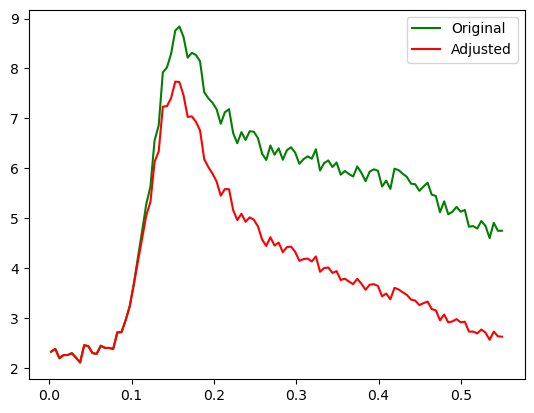

In [9]:
plt.plot(PFR_time_shortened,PFR_firing_rate_shortened,color='g',label='Original')
plt.plot(PFR_time_shortened,inh_PN_curve,color='r',label='Adjusted')
plt.legend()